Analyze customer order data to understand spending patterns and delivery performance.

In [4]:
import pandas as pd
import numpy as np

np.random.seed(42)

n = 200

data = {
    "order_id": range(1001, 1001 + n),
    "city": np.random.choice(["Mumbai", "Delhi", "Bangalore", "Chennai"], size=n),
    "category": np.random.choice(["Electronics", "Clothing", "Groceries", "Furniture"], size=n),
    "order_value": np.random.randint(200, 5000, size=n).astype(float),
    "delivery_days": np.random.randint(1, 15, size=n).astype(float),
    "rating": np.random.choice([1, 2, 3, 4, 5, None], size=n)
}

missing_indices_order = np.random.choice(n, size=15, replace=False)
missing_indices_delivery = np.random.choice(n, size=10, replace=False)
data["order_value"][missing_indices_order] = np.nan
data["delivery_days"][missing_indices_delivery] = np.nan

data["order_value"][5] = 95000
data["order_value"][88] = 87000

df = pd.DataFrame(data)
print(df.shape)
df.head()


(200, 6)


,order_id,city,category,order_value,delivery_days,rating
0,1001,Bangalore,Groceries,4191.0,11.0,4
1,1002,Chennai,Furniture,4923.0,12.0,1
2,1003,Mumbai,Groceries,4882.0,13.0,2
3,1004,Bangalore,Electronics,1848.0,13.0,1
4,1005,Bangalore,Furniture,1645.0,12.0,1


In [5]:
df.dtypes

order_id           int64
city              object
category          object
order_value      float64
delivery_days    float64
rating            object
dtype: object

In [6]:
df.isnull()

,order_id,city,category,order_value,delivery_days,rating
0,False,False,False,False,False,False
1,False,False,False,False,False,False
2,False,False,False,False,False,False
3,False,False,False,False,False,False
4,False,False,False,False,False,False
...,...,...,...,...,...,...
195,False,False,False,False,False,False
196,False,False,False,False,False,False
197,False,False,False,False,False,False
198,False,False,False,False,False,False


In [7]:
df.isnull().sum()

order_id          0
city              0
category          0
order_value      14
delivery_days    10
rating           32
dtype: int64

In [8]:
missing_percentage= (df.isnull().sum()/ len(df)) * 100
missing_percentage.round(2)

order_id          0.0
city              0.0
category          0.0
order_value       7.0
delivery_days     5.0
rating           16.0
dtype: float64

In [9]:
df.describe()

,order_id,order_value,delivery_days
count,200.000000,186.000000,190.000000
mean,1100.500000,3707.134409,7.810526
std,57.879185,9238.438378,4.075465
min,1001.000000,204.000000,1.000000
25%,1050.750000,1512.000000,4.000000
50%,1100.500000,2934.000000,8.000000
75%,1150.250000,3987.500000,12.000000
max,1200.000000,95000.000000,14.000000


OBSERVATION-1:
very high max(column)- order_value.

OBSERVATION-2:
large gap btw max & min(column)- delivery days

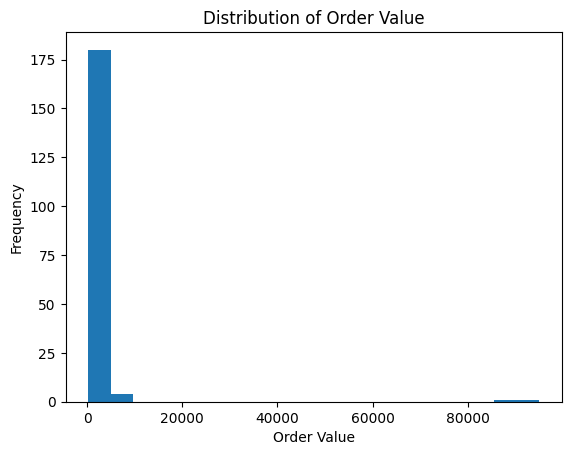

In [10]:
import matplotlib.pyplot as plt

plt.hist(df["order_value"], bins=20)
plt.title("Distribution of Order Value")
plt.xlabel("Order Value")
plt.ylabel("Frequency")
plt.show()

Most customers spend low amounts and few spends extreme high amounts(outliers).

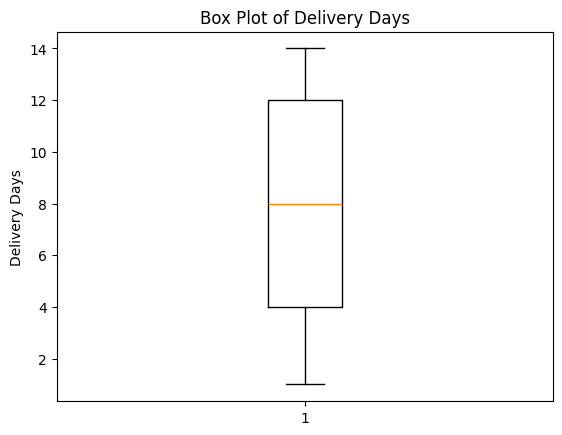

In [11]:
plt.boxplot(df["delivery_days"].dropna())
plt.title("Box Plot of Delivery Days")
plt.ylabel("Delivery Days")
plt.show()

Delivery is consistent (4-12 days)

average= 8 days

In [12]:
df.corr(numeric_only= True)

,order_id,order_value,delivery_days
order_id,1.000000,-0.095503,0.004858
order_value,-0.095503,1.000000,0.141660
delivery_days,0.004858,0.141660,1.000000


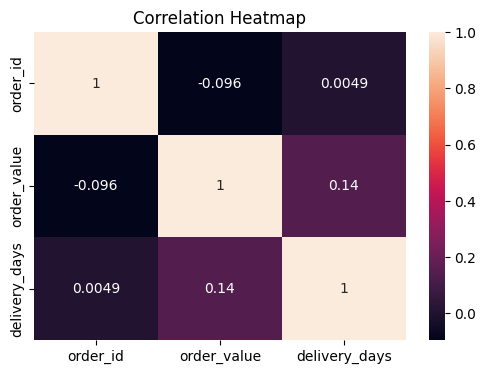

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns

corr_matrix = df.corr(numeric_only= True)

plt.figure(figsize=(6,4))
sns.heatmap(corr_matrix, annot= True)

plt.title("Correlation Heatmap")
plt.show()


The correlation heatmap shows that mostly values are close to 0, telling about the weak relationships between variables. the value 0.14 shows a slightly +ve correlation, but not strong.

In [16]:
city_sales= df.groupby("city")["order_value"].sum().sort_values(ascending=False)
city_sales

city
Chennai      330552.0
Bangalore    133114.0
Delhi        115232.0
Mumbai       110629.0
Name: order_value, dtype: float64

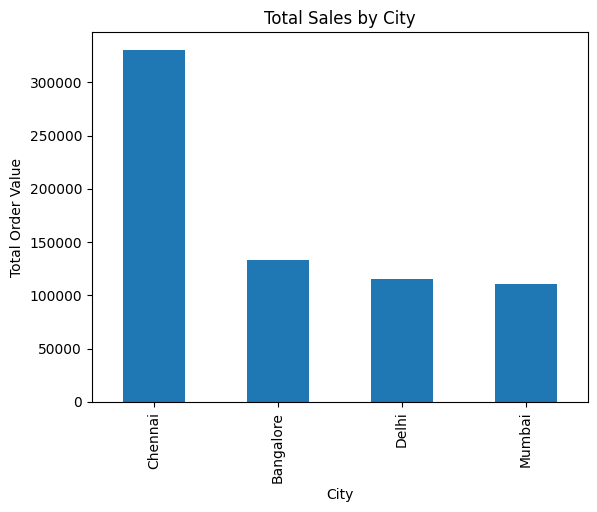

In [17]:
city_sales.plot(kind='bar')
plt.title("Total Sales by City")
plt.xlabel("City")
plt.ylabel("Total Order Value")
plt.show()

one city contributes highest total sales.

In [18]:
category_sales= df.groupby("category")["order_value"].sum().sort_values(ascending=False)
category_sales

category
Electronics    309224.0
Furniture      156921.0
Groceries      114686.0
Clothing       108696.0
Name: order_value, dtype: float64

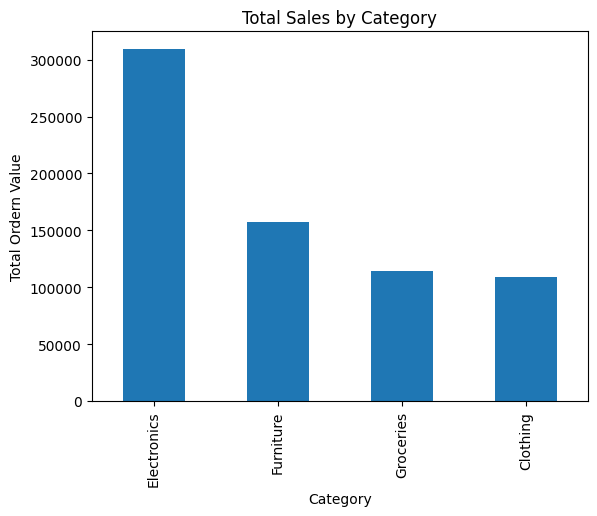

In [19]:
category_sales.plot(kind='bar')
plt.title("Total Sales by Category")
plt.xlabel("Category")
plt.ylabel("Total Ordern Value")
plt.show()

one category generated more sales, creating high demand for it.

In [25]:
avg_delivery= df.groupby("city")["delivery_days"].mean().sort_values()
avg_delivery

city
Delhi        7.418605
Mumbai       7.681818
Bangalore    7.780000
Chennai      8.264151
Name: delivery_days, dtype: float64

delivery time is consistent across cities.

In [21]:
df.groupby("rating")["order_value"].mean()

rating
1    2719.500000
2    5374.806452
3    2518.193548
4    3026.703704
5    2441.444444
Name: order_value, dtype: float64

no strong relationship btw ordervalue and rating, meaning higher spending does not give better ratings.

THE RESULT:

-customers mostly spend low amount.

-few orders are very expensive(outliers).

-delivery time is consistent and reliable.

-no strong relationship betwwen varaiables.